<a href="https://colab.research.google.com/github/christiewong219/Team-5-CS105-Final-Project/blob/main/Team_5_Phase_2_3.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [309]:
#pip install pandas numpy scikit-learn matplotlib seaborn scipy nltk sentence-transformers

In [310]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay

from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB

from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.decomposition import PCA

from sklearn.metrics.pairwise import cosine_similarity
from scipy.cluster.hierarchy import linkage, dendrogram

from sklearn.neighbors import KNeighborsClassifier
from scipy.optimize import linear_sum_assignment
from sklearn.preprocessing import Normalizer

from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

from sklearn.cluster import DBSCAN
from sklearn.decomposition import TruncatedSVD

from sklearn.svm import LinearSVC
from sentence_transformers import SentenceTransformer
from sklearn.metrics import adjusted_rand_score
RANDOM_STATE = 42

In [311]:
try:
    from google.colab import drive
    drive.mount('/content/drive')
except:
    print("Not running in Google Colab, skipping drive mount.")

Not running in Google Colab, skipping drive mount.


# **CS105 Final Project**

**Project Description**

We will be analyzing a corpus (roughly 800 documents) created by UCR students using various Natura Language Processing methods. This includes the beginning process of text preparation, tokenization, pre-processing, and algorithm implementation. We will be answering various questions with the useage of Supervised and Unsupervised algorithms. Finally, we will be using various libraries, such as VADER and BERT, to test and compare our results.

## **Phase 2: Supervised Learning**
The purpose of this project is to use the corpus created in Phase 1 for supervised learning to analyze and measure the document.
* We will read and tokenize the documents.
* Vectorize the corpus using Bag-of-Words (BoW) or one-hot encoding (OHE).
* Apply TF-IDF to the BoW representation, and compare the results with the original BoW representation for
at least some tasks.

### Preparing Data

Read the corpus from phase 1 and drop the incomplete row.

In [312]:
# Loading data
df = pd.read_csv("AllCorpus - Corpus.csv")
print(df.shape)

# Drop empty rows
df = df.dropna()
df.head()
print(df.shape)


(810, 5)
(693, 5)


### **Converting the documents**
#### **Tokenize the text**
* We clean the text column by making each word to lowercase and remove all the symbol.
* Then spilt each word and tokenize them.


In [313]:
# standardize the text and remove signs
def clean(text):
  text = text.lower()
  text = re.sub(r'[^a-z0-9\s]', '', text)
  tokens = text.split()
  return str(tokens)
  #return

df['text'] = df['text'].apply(clean)

# standardize the labels for sentiment
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.replace('.', '', regex=False).str.lower()
typo_map = {
  'netural': 'neutral',
  'nuetral': 'neutral',
  'positve': 'positive',
  'negative': 'negative'
}
df['sentiment'] = df['sentiment'].replace(typo_map)
df.head()

,doc_id,text,category_1,category_2,sentiment
0,1,"['trumps', 'presidency', 'has', 'been', 'tatte...",1,none,negative
1,2,"['my', 'machine', 'learning', 'course', 'has',...",2,none,positive
2,3,"['the', 'plot', 'of', 'the', 'final', 'season'...",3,none,negative
3,4,"['i', 'enjoy', 'getting', 'learning', 'about',...",4,none,positive
4,5,"['its', 'concerning', 'our', 'government', 'is...",1,2,negative


#### **Vectorization**

* Remove the common english word use for filler without any meaning
* Generate the matrixes with three different ways for training models.
* convert to dataframe with each words apears/frequency/weight for each corpus.

In [314]:
# remove common filler words
bow_vectorizer = CountVectorizer(stop_words="english")
binary_vectorizer = CountVectorizer(stop_words="english", binary=True)
tfidf_vectorizer = TfidfVectorizer(stop_words="english", max_df=0.85, min_df=2, ngram_range=(1, 2), max_features=1000)

# count the amount of time each word appears
X_bow = bow_vectorizer.fit_transform(df["text"])

# One-hot Encoded, track if the word exist
X_binary = binary_vectorizer.fit_transform(df["text"])

# score a word to the dataset - weight
X_tfidf = tfidf_vectorizer.fit_transform(df["text"])

bow_df = pd.DataFrame(X_bow.toarray(), columns=bow_vectorizer.get_feature_names_out())
binary_df = pd.DataFrame(X_binary.toarray(), columns=binary_vectorizer.get_feature_names_out())
tfidf_df = pd.DataFrame(np.round(X_tfidf.toarray(), 2), columns=tfidf_vectorizer.get_feature_names_out())

print(bow_df.head())
print(binary_df.head())
print(tfidf_df.head())

#print(bow_df.shape)
print(binary_df.shape)
print(tfidf_df.shape)



   10  10000  111  12  1990s  2026  2028  30  5150  5k  ...  year  years  \
0   0      0    0   0      0     0     0   0     0   0  ...     0      0   
1   0      0    0   0      0     0     0   0     0   0  ...     0      0   
2   0      0    0   0      0     0     0   0     0   0  ...     0      0   
3   0      0    0   0      0     0     0   0     0   0  ...     0      0   
4   0      0    0   0      0     0     0   0     0   0  ...     0      0   

   yesterdays  yoga  young  younger  youtube  zones  zongs  zoomies  
0           0     0      0        0        0      0      0        0  
1           0     0      0        0        0      0      0        0  
2           0     0      0        0        0      0      0        0  
3           0     0      0        0        0      0      0        0  
4           0     0      0        0        0      0      0        0  

[5 rows x 3452 columns]
   10  10000  111  12  1990s  2026  2028  30  5150  5k  ...  year  years  \
0   0      0    0   0 

### **Logistic Regression**
We are comparing category classification between TF-IDF and BoW representations to see which one performs better or worse. We also used ROC Curves and took a one-vs-rest (OvR) approach to see how well each category can be distinguished compared to the other categories between both the BoW and TF-IDF models.

Accuracy from BoW: 0.81429
              precision    recall  f1-score   support

           1       0.94      0.89      0.92        19
           2       0.76      1.00      0.86        16
           3       0.82      0.69      0.75        13
           4       0.83      0.77      0.80        13
           5       0.62      0.56      0.59         9

    accuracy                           0.81        70
   macro avg       0.80      0.78      0.78        70
weighted avg       0.82      0.81      0.81        70

Accuracy from TF-IDF: 0.75714
              precision    recall  f1-score   support

           1       0.76      0.84      0.80        19
           2       0.71      0.94      0.81        16
           3       0.70      0.54      0.61        13
           4       0.92      0.85      0.88        13
           5       0.67      0.44      0.53         9

    accuracy                           0.76        70
   macro avg       0.75      0.72      0.73        70
weighted avg       0

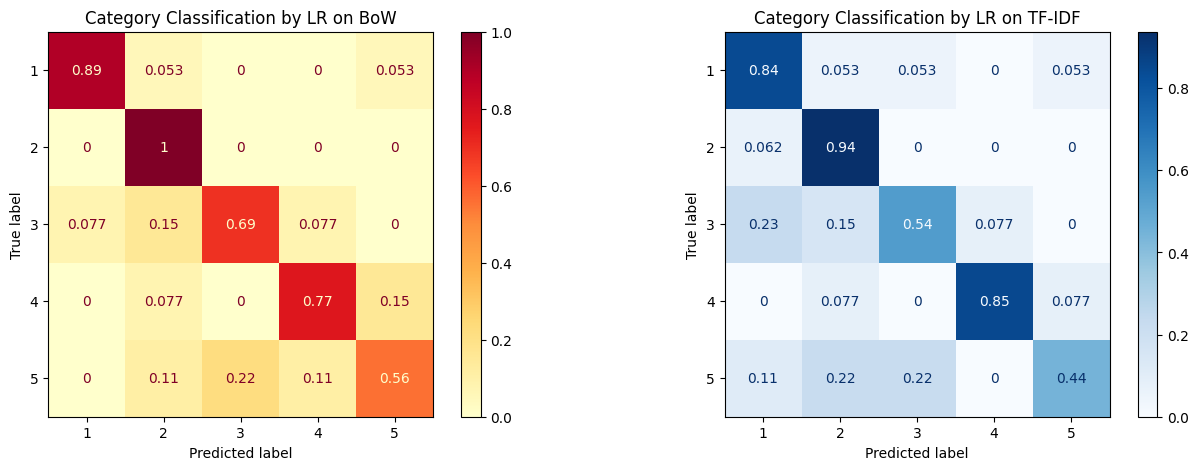

In [315]:
log_model_bow = LogisticRegression(max_iter = 200, random_state = RANDOM_STATE)
log_model_tfidf = LogisticRegression(max_iter = 200, random_state = RANDOM_STATE)
indices = np.arange(len(df))

# 90/10 training test split
X_train_idx, X_test_idx, y_train, y_test = train_test_split(
    indices,
    df["category_1"],
    test_size = 0.1,
    random_state=RANDOM_STATE,
    stratify=df["category_1"]
)

X_train_bow, X_test_bow = X_bow[X_train_idx], X_bow[X_test_idx]
X_train_tfidf, X_test_tfidf = X_tfidf[X_train_idx], X_tfidf[X_test_idx]

log_model_bow.fit(X_train_bow, y_train)
y_pred_bow = log_model_bow.predict(X_test_bow)
accuracy_bow = accuracy_score(y_test, y_pred_bow)

log_model_tfidf.fit(X_train_tfidf, y_train)
y_pred_tfidf = log_model_tfidf.predict(X_test_tfidf)
accuracy_tfidf = accuracy_score(y_test, y_pred_tfidf)

# accuracy + performance
print(f"Accuracy from BoW: {accuracy_bow:.5f}")
print(classification_report(y_test, y_pred_bow, zero_division = 0))
print(f"Accuracy from TF-IDF: {accuracy_tfidf:.5f}")
print(classification_report(y_test, y_pred_tfidf, zero_division = 0))

# plotting confusion matrices
fig, axes = plt.subplots(1, 2, figsize = (16, 5))
cm_bow = confusion_matrix(y_test, y_pred_bow, normalize = "true")
cm_tfidf = confusion_matrix(y_test, y_pred_tfidf, normalize = "true")

# fixing labels
cat_labels = sorted(df["category_1"].unique())

ConfusionMatrixDisplay(cm_bow, display_labels = cat_labels).plot(ax = axes[0], cmap = "YlOrRd")
axes[0].set_title("Category Classification by LR on BoW")
ConfusionMatrixDisplay(cm_tfidf, display_labels = cat_labels).plot(ax = axes[1], cmap = "Blues")
axes[1].set_title("Category Classification by LR on TF-IDF")

plt.show()

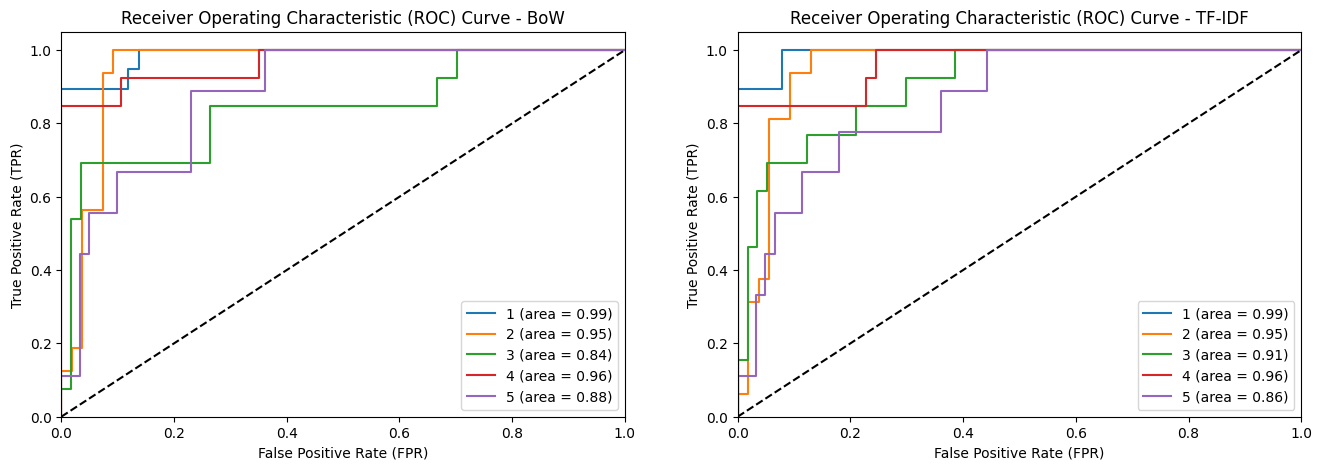

In [316]:
# roc curves

# Predict probabilities
y_prob_bow = log_model_bow.predict_proba(X_test_bow)
y_prob_tfidf = log_model_tfidf.predict_proba(X_test_tfidf)
classes = log_model_bow.classes_

# binarize category labels,
y_bin = label_binarize(y_test, classes = classes)

# plotting curves
fig, axes = plt.subplots(1, 2, figsize = (16, 5))

# looping to calc roc and auc for both bow and tfidf
for i, class_label in enumerate(classes):
    fpr_bow, tpr_bow, _ = roc_curve(y_bin[:, i], y_prob_bow[:, i])
    fpr_tfidf, tpr_tfidf, _ = roc_curve(y_bin[:, i], y_prob_tfidf[:, i])
    roc_auc_bow = auc(fpr_bow, tpr_bow)
    roc_auc_tfidf = auc(fpr_tfidf, tpr_tfidf)
    axes[0].plot(fpr_bow, tpr_bow, label = f"{class_label} (area = {roc_auc_bow:.2f})")
    axes[1].plot(fpr_tfidf, tpr_tfidf, label = f"{class_label} (area = {roc_auc_tfidf:.2f})")

axes[0].plot([0, 1], [0, 1], "k--")
axes[0].set_xlim([0.0, 1.0])
axes[0].set_ylim([0.0, 1.05])
axes[0].set_xlabel("False Positive Rate (FPR)")
axes[0].set_ylabel("True Positive Rate (TPR)")
axes[0].set_title("Receiver Operating Characteristic (ROC) Curve - BoW")
axes[0].legend(loc = "lower right")

axes[1].plot([0, 1], [0, 1], "k--")
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel("False Positive Rate (FPR)")
axes[1].set_ylabel("True Positive Rate (TPR)")
axes[1].set_title("Receiver Operating Characteristic (ROC) Curve - TF-IDF")
axes[1].legend(loc = "lower right")

**Analyze:**
The BoW model seemed to have the higher accuracy score about 81% compared to the accuracy score of about 74% for the TF-IDF model. The recall rates for Category 1 are the highest for both models with TF-IDF doing a little bit better. The recall rates are also high for Categories 2 and 4 with BoW having the better performance. For Categories 3 and 5, TF-IDF seems to perform worse with the lower recall rates. Noticably for both categories, TF-IDF seems to misclassify some instances as Category 1. This may be due to having some vocabulary words or topics overlapping across these categories.

Then, we created ROC curves to visualize how well both models can distinguish between one category from all the others. TF-IDF seems to perform slightly better across all the categories, but overall, the AUC scores are above 0.84 which show good predictive power.

### **Multinomial Naive Bayes**
We compare the Bag-of-words representation with the TF-IDF representation. MNB is a probabilistic classifier that uses Bayes Theorem. It is very efficient and scales well to high dimensional vocab spaces.

BoW Accuracy: 0.7758620689655172
              precision    recall  f1-score   support

           1       0.92      0.77      0.84        47
           2       0.73      0.95      0.82        39
           3       0.77      0.61      0.68        33
           4       0.88      0.85      0.87        34
           5       0.52      0.62      0.57        21

    accuracy                           0.78       174
   macro avg       0.76      0.76      0.75       174
weighted avg       0.79      0.78      0.78       174

TF-IDF Accuracy: 0.8103448275862069
              precision    recall  f1-score   support

           1       0.84      0.81      0.83        47
           2       0.74      0.95      0.83        39
           3       0.77      0.73      0.75        33
           4       0.91      0.91      0.91        34
           5       0.79      0.52      0.63        21

    accuracy                           0.81       174
   macro avg       0.81      0.78      0.79       174
weighted

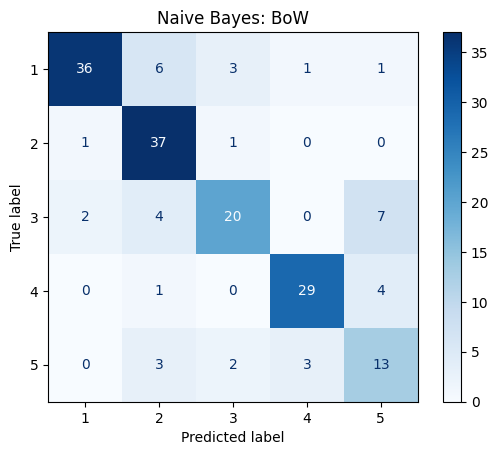

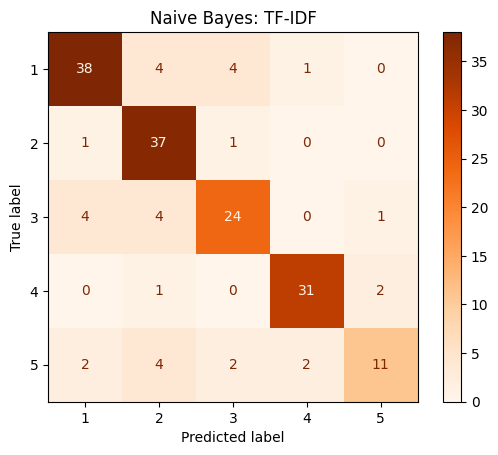

In [317]:
# this is one shared split
indices = np.arange(len(df))
idx_train, idx_test, y_train, y_test = train_test_split(
    indices,
    df["category_1"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["category_1"]
)

X_train_bow, X_test_bow = X_bow[idx_train], X_bow[idx_test]
X_train_tfidf, X_test_tfidf = X_tfidf[idx_train], X_tfidf[idx_test]

# alpha of 0.5 works for 810 documents that averate ~22 words
# eval BoW
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_bow, y_train)
y_pred_bow = nb.predict(X_test_bow)
acc_score_bow = accuracy_score(y_test, y_pred_bow)

print("BoW Accuracy:", acc_score_bow)
print(classification_report(y_test, y_pred_bow, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_bow, cmap='Blues')
plt.title("Naive Bayes: BoW")

# eval td-idf
nb = MultinomialNB(alpha=0.5)
nb.fit(X_train_tfidf, y_train)
y_pred_tfidf = nb.predict(X_test_tfidf)
acc_score_tfidf = accuracy_score(y_test, y_pred_tfidf)

print("TF-IDF Accuracy:", acc_score_tfidf)
print(classification_report(y_test, y_pred_tfidf, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_tfidf, cmap='Oranges')
plt.title("Naive Bayes: TF-IDF")

if acc_score_bow > acc_score_tfidf:
    print("BoW has better accuracy than TF-IDF.")
elif acc_score_tfidf > acc_score_bow:
    print("TF-IDF has better accuracy than BoW.")
else:
    print("BoW and TF-IDF have equal accuracy.")

plt.show()

**Analyze**: The accuracy was close - TF-IDF has an accuracy of 0.81 adn BoW had 0.78. With category 2, both tied at 0.95 recall. Category 3 became more sensitive, which TF-IDF recall going to 0.73 and BoW recall going down to 0.61. For class 5, precision was 0.79 for TF-IDF but dropped all the way to 0.52 for BoW. However, recall for category 5 was lower for TF-iDF, where it was 0.52 while it was 0.62 for BoW.

Therefore, TF-IDF is the better text representation method for the MNB classifier.

### **kNN (Binary feature comparison)**
This compares how a distance classifier performs when the dataset is reduced to only the presence of vocab words.

Binary kNN Accuracy:  0.7701149425287356
              precision    recall  f1-score   support

           1       0.84      0.87      0.85        47
           2       0.73      0.95      0.82        39
           3       0.74      0.61      0.67        33
           4       0.82      0.79      0.81        34
           5       0.64      0.43      0.51        21

    accuracy                           0.77       174
   macro avg       0.75      0.73      0.73       174
weighted avg       0.77      0.77      0.76       174

Accuracy: 0.764367816091954
              precision    recall  f1-score   support

           1       0.86      0.79      0.82        47
           2       0.71      0.92      0.80        39
           3       0.77      0.70      0.73        33
           4       0.79      0.76      0.78        34
           5       0.65      0.52      0.58        21

    accuracy                           0.76       174
   macro avg       0.75      0.74      0.74       174
weighted

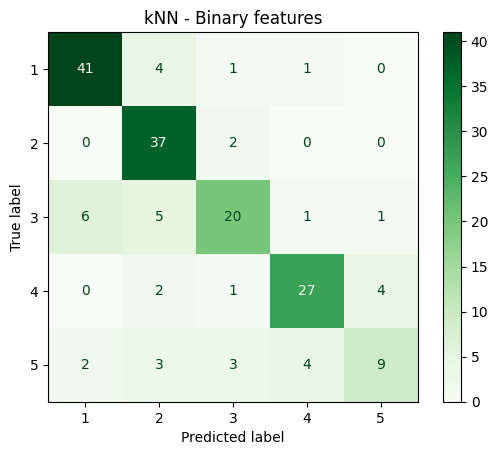

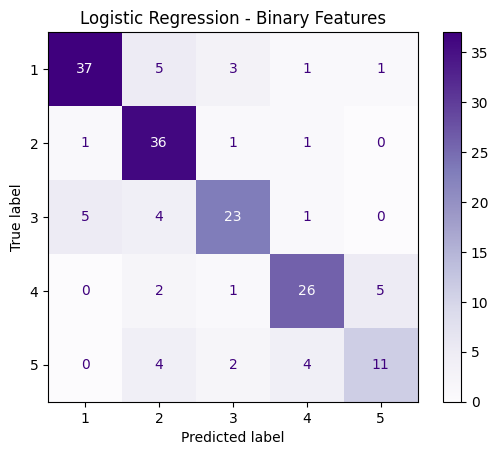

In [318]:
X_train_bin, X_test_bin = X_binary[idx_train], X_binary[idx_test]

k = int(np.sqrt(len(y_train)))
if k % 2 == 0:
    k += 1

# cosine sim for curse of dimensionality
knn_bin = KNeighborsClassifier(n_neighbors=k, metric='cosine')
knn_bin.fit(X_train_bin, y_train)
y_pred_knn_bin = knn_bin.predict(X_test_bin)
acc_score_knn_bin = accuracy_score(y_test, y_pred_knn_bin)

print("Binary kNN Accuracy: ", acc_score_knn_bin)
print(classification_report(y_test, y_pred_knn_bin, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_knn_bin, cmap='Greens')
plt.title("kNN - Binary features")

log_bin = LogisticRegression(random_state=RANDOM_STATE, max_iter=200)
log_bin.fit(X_train_bin, y_train)
y_pred_log_bin = log_bin.predict(X_test_bin)
acc_score_log_bin = accuracy_score(y_test, y_pred_log_bin)

print("Accuracy:", acc_score_log_bin)
print(classification_report(y_test, y_pred_log_bin, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test, y_pred_log_bin, cmap='Purples')
plt.title("Logistic Regression - Binary Features")

plt.show()

**Analyze**: Logistic regression had a 0.76 accruacy while binary kNN has 0.77. The largest recall difference was in category 3/5: the recall for kNN was lower by 0.09 for both of those categories. For category 3, kNN's recall was 0.61 while logistic regressions was 0.70. And for category 5, kNN's recall was 0.43 while logistic regression's was 0.52. kNN artifically inflates its own accuracy by perfoming better on the largest category and worse on the smaller ones.

Therefore, Logistic regression is better for binary features than kNN due to these results.

### **Sentiment prediction with random forest**

Random forest is an algorithm that makes many decision trees during training and outputs the maj consensus of their individual votes for classification. It is good for linear relationships, so it might work with sentiment. Remember, each sentence has a sentiment - either positive, negative, or neutral.



0 rows had sentiment typos.
Random Forest Sentiment Accuracy:  0.7211538461538461
              precision    recall  f1-score   support

    negative       0.96      0.76      0.85        34
     neutral       0.60      0.73      0.66        33
    positive       0.68      0.68      0.68        37

    accuracy                           0.72       104
   macro avg       0.75      0.72      0.73       104
weighted avg       0.75      0.72      0.73       104



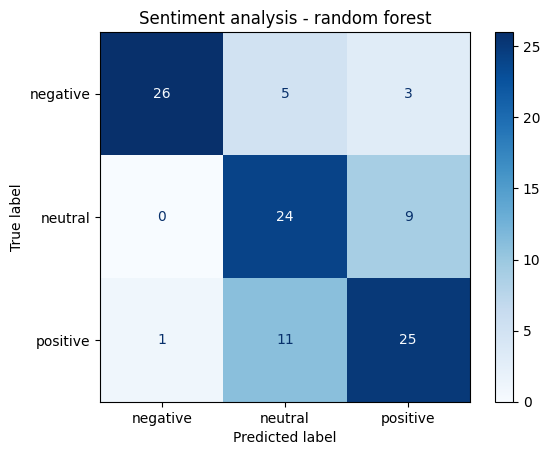

In [319]:
from sklearn.ensemble import RandomForestClassifier

# there are some typos from some silly people - purge them
df['sentiment'] = df['sentiment'].astype(str).str.strip().str.lower()
mask = df['sentiment'].isin(['positive', 'negative', 'neutral'])
df_rf = df[mask]
X_tfidf_rf = X_tfidf[mask.values]

print(f"{len(df) - len(df_rf)} rows had sentiment typos.")

X_train_rf, X_test_rf, y_train_rf, y_test_rf = train_test_split(
    X_tfidf_rf,
    df_rf["sentiment"],
    test_size=0.15,
    random_state=RANDOM_STATE,
    stratify=df_rf["sentiment"]
)

rf_model = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE, class_weight='balanced')
rf_model.fit(X_train_rf, y_train_rf)
y_pred_rf = rf_model.predict(X_test_rf)
acc_score_rf = accuracy_score(y_test_rf, y_pred_rf)

print("Random Forest Sentiment Accuracy: ", acc_score_rf)
print(classification_report(y_test_rf, y_pred_rf, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test_rf, y_pred_rf, cmap='Blues')
plt.title("Sentiment analysis - random forest")
plt.show()

**Analyze**: I changes the test/train split to 0.15 because the model needed better tuning to be able to make out any results. The final accuracy came out to be 0.72. The negative class precision was very high at 0.96, which recall was 0.76. On the other hand, positive was much worse with a 0.68 precision and recall. Neutral had the worst performance overall with a precision of 0.60 and recall of 0.73. It is very reliable when it comes to predicting documents that definitely have a negative sentiment, but it gets confused with predicting neutral/positive sentiment documents.

Therefore, this is not a good model to measure with overall.

### **Support Vector Machine (SVM)**

This uses a linear SVM to predict the primary category of each document. 

(Satisfies - Additional supervised method.) (Satisfies - Compare BoW and TF-IDF representations for a supervised task.)

SVM BoW Accuracy: 0.72989
              precision    recall  f1-score   support

           1       0.83      0.81      0.82        47
           2       0.71      0.90      0.80        39
           3       0.73      0.58      0.64        33
           4       0.69      0.71      0.70        34
           5       0.61      0.52      0.56        21

    accuracy                           0.73       174
   macro avg       0.71      0.70      0.70       174
weighted avg       0.73      0.73      0.73       174

SVM TF-IDF Accuracy: 0.77011
              precision    recall  f1-score   support

           1       0.86      0.81      0.84        47
           2       0.71      0.92      0.80        39
           3       0.77      0.70      0.73        33
           4       0.80      0.71      0.75        34
           5       0.68      0.62      0.65        21

    accuracy                           0.77       174
   macro avg       0.76      0.75      0.75       174
weighted avg       0.7

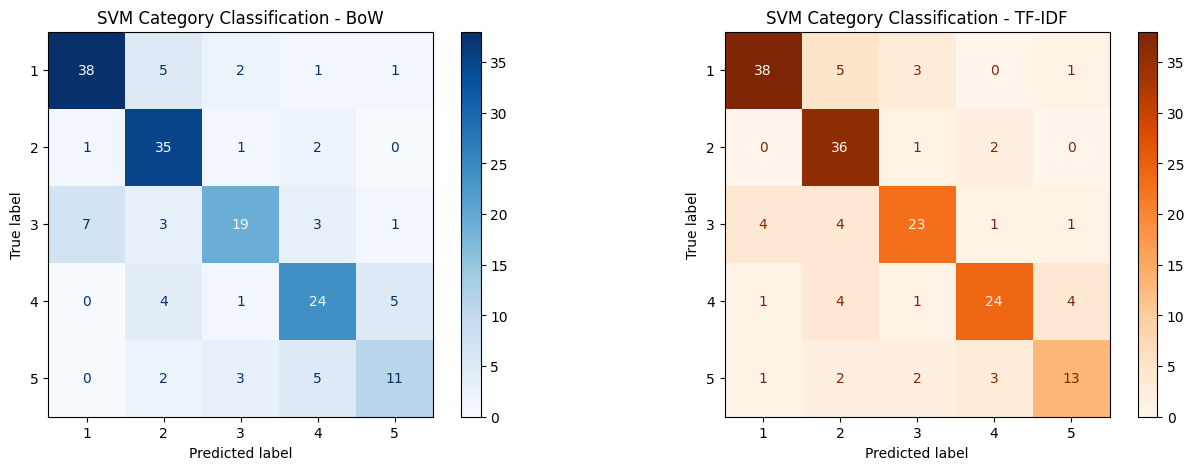

TF-IDF performed better than BoW for the SVM model.


In [320]:
indexes = np.arange(len(df))

idx_train, idx_test, y_train, y_test = train_test_split(
    indexes,
    df["category_1"],
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=df["category_1"]
)

X_train_bow = X_bow[idx_train]
X_test_bow = X_bow[idx_test]
X_train_tfidf = X_tfidf[idx_train]
X_test_tfidf = X_tfidf[idx_test]

svm_bow = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)
svm_tfidf = LinearSVC(random_state=RANDOM_STATE, max_iter=5000)

svm_bow.fit(X_train_bow, y_train)
y_pred_svm_bow = svm_bow.predict(X_test_bow)

svm_tfidf.fit(X_train_tfidf, y_train)
y_pred_svm_tfidf = svm_tfidf.predict(X_test_tfidf)

svm_bow_acc = accuracy_score(y_test, y_pred_svm_bow)
svm_tfidf_acc = accuracy_score(y_test, y_pred_svm_tfidf)

print(f"SVM BoW Accuracy: {svm_bow_acc:.5f}")
print(classification_report(y_test, y_pred_svm_bow, zero_division=0))

print(f"SVM TF-IDF Accuracy: {svm_tfidf_acc:.5f}")
print(classification_report(y_test, y_pred_svm_tfidf, zero_division=0))

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_bow,
    ax=axes[0],
    cmap="Blues"
)
axes[0].set_title("SVM Category Classification - BoW")

ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred_svm_tfidf,
    ax=axes[1],
    cmap="Oranges"
)
axes[1].set_title("SVM Category Classification - TF-IDF")

plt.show()

# State is "random", so dynamically call the result
if svm_bow_acc > svm_tfidf_acc:
    print("BoW performed better than TF-IDF for the SVM model.")
elif svm_tfidf_acc > svm_bow_acc:
    print("TF-IDF performed better than BoW for the SVM model.")
else:
    print("BoW and TF-IDF performed equally for the SVM model.")

**Analyze:** The SVM model performed slightly better with TF-IDF than with BoW when the random state is 42. The BoW model had an accuracy of 0.73, while the TF-IDF model had an accuracy of 0.76. Thus, giving words different weights based on importance helped the SVM model classify documents more accurately than using only word counts.

Looking at the classification reports, both models performed well on categories 1 and 2. TF-IDF had stronger results for category 3 and category 5, improving their recall and F1-scores compared to BoW. catagory 5 was still the weakest overall, most likely because it had fewer test examples and probably shares vocabulary with other categories.

The confusion matrices show that most documents were classified correctly along the diagonal, but there were still some errors between related categories. For example, some category 3 documents were predicted as category 1 or 2, and some category 5 documents were predicted as category 4. Again, this may be because some documents contain overlapping vocabulary or combine multiple topics.

Therefore, TF-IDF is the better representation for the SVM model in this experiment.


### **Sentiment prediction with KNN**

This task use a KNN to predict the sentimental.
1. Find optimal K using an elbow method
2. Using the K and use KNN on Binary feature and TF-IDF feature. Compare the confusing matric to see the different.

Optimal K for Binary kNN: 3 with test accuracy 0.5747
Optimal K for TF-IDF kNN: 14 with test accuracy 0.5287


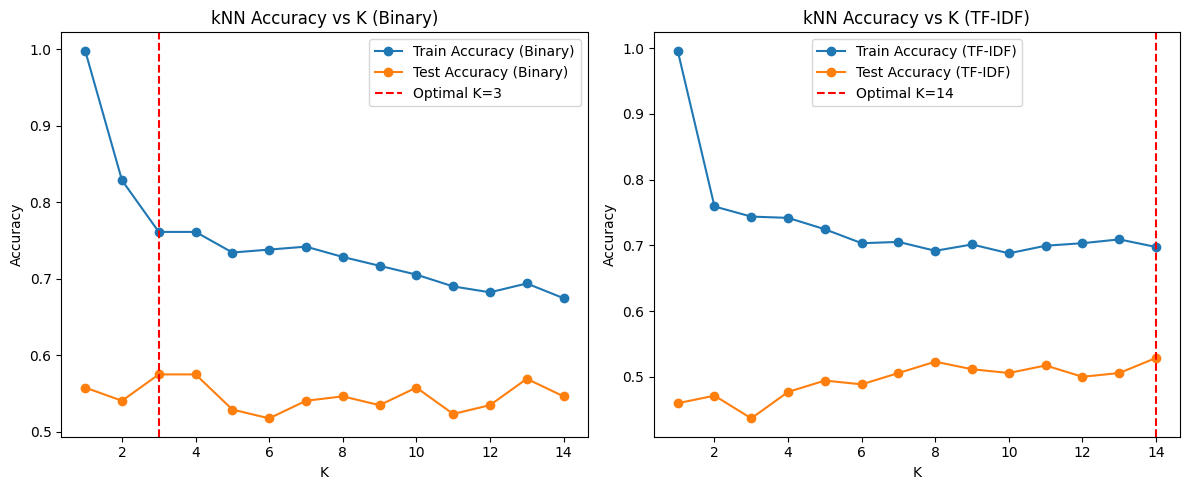

In [321]:
df_clean = df[mask].reset_index(drop=True)
y_sentiment = df_clean["sentiment"]
# split the data into train and test sets 75/25 split X_binary,
X_train_bin, X_test_bin, y_train_bin, y_test_bin = train_test_split(
    X_binary[mask.values], y_sentiment, test_size=0.25, random_state=RANDOM_STATE, stratify=y_sentiment
)
X_train_tfidf, X_test_tfidf, y_train_tfidf, y_test_tfidf = train_test_split(
    X_tfidf[mask.values], y_sentiment, test_size=0.25, random_state=RANDOM_STATE, stratify=y_sentiment
)

#Find the optimal K value for kNN using the elbow method
k_values = range(1, 15)
train_accuracies_binary = []
test_accuracies_binary = []
train_accuracies_tfidf = []
test_accuracies_tfidf = []

for k in k_values:
    knn_bin = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn_bin.fit(X_train_bin, y_train_bin)
    train_accuracies_binary.append(knn_bin.score(X_train_bin, y_train_bin))
    test_accuracies_binary.append(knn_bin.score(X_test_bin, y_test_bin))

    knn_tfidf = KNeighborsClassifier(n_neighbors=k, metric='cosine')
    knn_tfidf.fit(X_train_tfidf, y_train_tfidf)
    train_accuracies_tfidf.append(knn_tfidf.score(X_train_tfidf, y_train_tfidf))
    test_accuracies_tfidf.append(knn_tfidf.score(X_test_tfidf, y_test_tfidf))

optimal_k_binary = k_values[np.argmax(test_accuracies_binary)]
optimal_k_tfidf = k_values[np.argmax(test_accuracies_tfidf)]
print(f"Optimal K for Binary kNN: {optimal_k_binary} with test accuracy {max(test_accuracies_binary):.4f}")
print(f"Optimal K for TF-IDF kNN: {optimal_k_tfidf} with test accuracy {max(test_accuracies_tfidf):.4f}")

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(k_values, train_accuracies_binary, label='Train Accuracy (Binary)', marker='o')
plt.plot(k_values, test_accuracies_binary, label='Test Accuracy (Binary)', marker='o')
plt.axvline(optimal_k_binary, color='red', linestyle='--', label=f'Optimal K={optimal_k_binary}')
plt.title('kNN Accuracy vs K (Binary)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(k_values, train_accuracies_tfidf, label='Train Accuracy (TF-IDF)', marker='o')
plt.plot(k_values, test_accuracies_tfidf, label='Test Accuracy (TF-IDF)', marker='o')
plt.axvline(optimal_k_tfidf, color='red', linestyle='--', label=f'Optimal K={optimal_k_tfidf}')
plt.title('kNN Accuracy vs K (TF-IDF)')
plt.xlabel('K')
plt.ylabel('Accuracy')
plt.legend()
plt.tight_layout()
plt.show()


Optimal Binary kNN Accuracy:  0.5747126436781609
Optimal TF-IDF kNN Accuracy:  0.5287356321839081
              precision    recall  f1-score   support

    negative       0.59      0.68      0.63        56
     neutral       0.59      0.39      0.47        56
    positive       0.55      0.65      0.59        62

    accuracy                           0.57       174
   macro avg       0.58      0.57      0.57       174
weighted avg       0.58      0.57      0.57       174

              precision    recall  f1-score   support

    negative       0.57      0.70      0.62        56
     neutral       0.47      0.39      0.43        56
    positive       0.53      0.50      0.52        62

    accuracy                           0.53       174
   macro avg       0.52      0.53      0.52       174
weighted avg       0.52      0.53      0.52       174



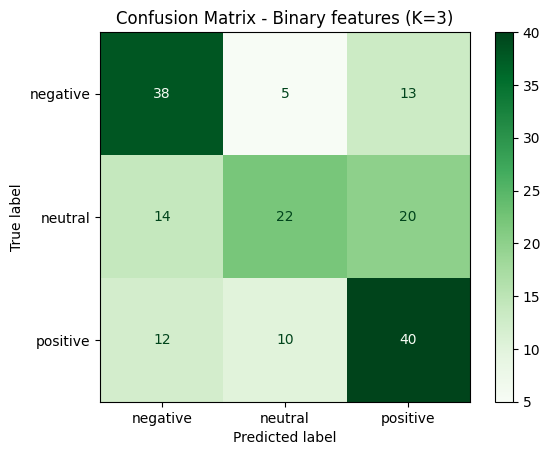

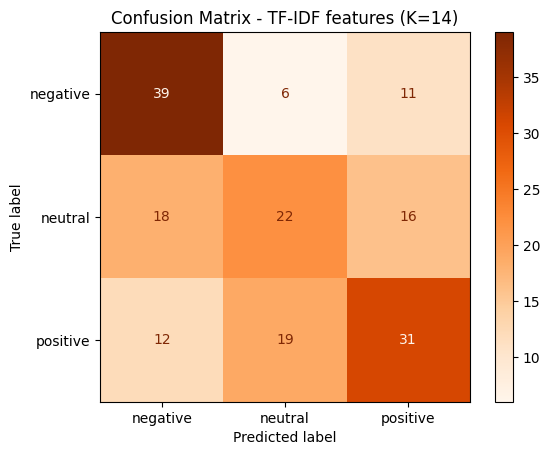

In [322]:
# Evaluate the optimal kNN models with the best K values
knn_bin_optimal = KNeighborsClassifier(n_neighbors=optimal_k_binary, metric='cosine')
knn_bin_optimal.fit(X_train_bin, y_train_bin)

y_pred_knn_bin_optimal = knn_bin_optimal.predict(X_test_bin)
acc_score_knn_bin_optimal = accuracy_score(y_test_bin, y_pred_knn_bin_optimal)
print("Optimal Binary kNN Accuracy: ", acc_score_knn_bin_optimal)

knn_tfidf_optimal = KNeighborsClassifier(n_neighbors=optimal_k_tfidf, metric='cosine')
knn_tfidf_optimal.fit(X_train_tfidf, y_train_tfidf)
y_pred_knn_tfidf_optimal = knn_tfidf_optimal.predict(X_test_tfidf)
acc_score_knn_tfidf_optimal = accuracy_score(y_test_tfidf, y_pred_knn_tfidf_optimal)
print("Optimal TF-IDF kNN Accuracy: ", acc_score_knn_tfidf_optimal)
print(classification_report(y_test_bin, y_pred_knn_bin_optimal, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test_bin, y_pred_knn_bin_optimal, cmap='Greens')

# plot confusion matrices for optimal kNN models
plt.title(f"Confusion Matrix - Binary features (K={optimal_k_binary})")
print(classification_report(y_test_tfidf, y_pred_knn_tfidf_optimal, zero_division=0))
ConfusionMatrixDisplay.from_predictions(y_test_tfidf, y_pred_knn_tfidf_optimal, cmap='Oranges')
plt.title(f"Confusion Matrix - TF-IDF features (K={optimal_k_tfidf})")
plt.show()

**Analyze**: The binary feature kNN has an accuracy of 0.57 while the TF-IDF kNN has an accuracy of 0.55. The binary feature kNN is better at predicting the positive and negative sentiment, while the TF-IDF kNN is better at predicting the neutral sentiment. This is because the binary feature kNN is more sensitive to the presence of certain words that are indicative of positive or negative sentiment, while the TF-IDF kNN is more sensitive to the overall frequency of words in the document.

The gap between the two models is not very large since the binary feature kNN is better at predicting the sentiment of the documents. Each document is relatively short, the presence of certain words is more important than the overall frequency of words in the document. Therefore, the binary feature kNN is better at capturing the sentiment of the documents. Additonally, KNN is a distance base between point, and dimension of binary is (693, 3452) and TF-IDF is (693, 1000). To calculate this amount of dimension, the distance between a true nearest neighbor and a completely random document becomes almost identical. The kNN voting pool fills with spatial noise.

## **Phase 3: Unsupervised Learning**
Furthering into Phase 3, we will follow similar methods and steps within the previous phase. Using the same vectorization methods as well as preprocessing methods, we will use unsupervised learning algorithms to develop and bring hidden clusters within the dataset into view.

### **K-Means Clustering**


**Question 1: Which categories are most similar to each other?**
In this task, we will use K-Means clustering to predict the similar vocabulary between each category. Due to some documents are in 2 categories, we will only use the documents that belong to one category. Additionally, the samples are randomly pick from each category with the same amount of sample. There are 5 catergory, therefore, the value of K is 5 and it will choose the random centriod. Then we cross table to find the score between each category and present them in percentage.


(297, 5)
54
category_1
1    54
2    54
3    54
4    54
5    54
Name: count, dtype: int64

 Similarity Cross table in Percentage
Predicted Category     1     2     3     4     5
True Category                                   
1                   87.0   0.0  13.0   0.0   0.0
2                    1.9  55.6  38.9   3.7   0.0
3                    5.6   0.0  94.4   0.0   0.0
4                    0.0   0.0  31.5  68.5   0.0
5                    1.9   0.0  44.4   0.0  53.7


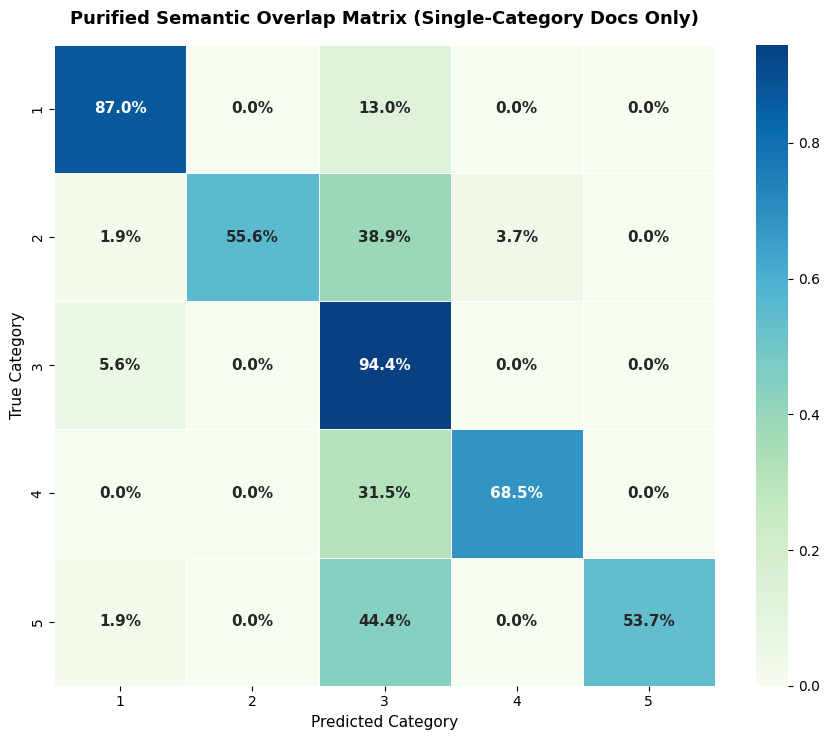

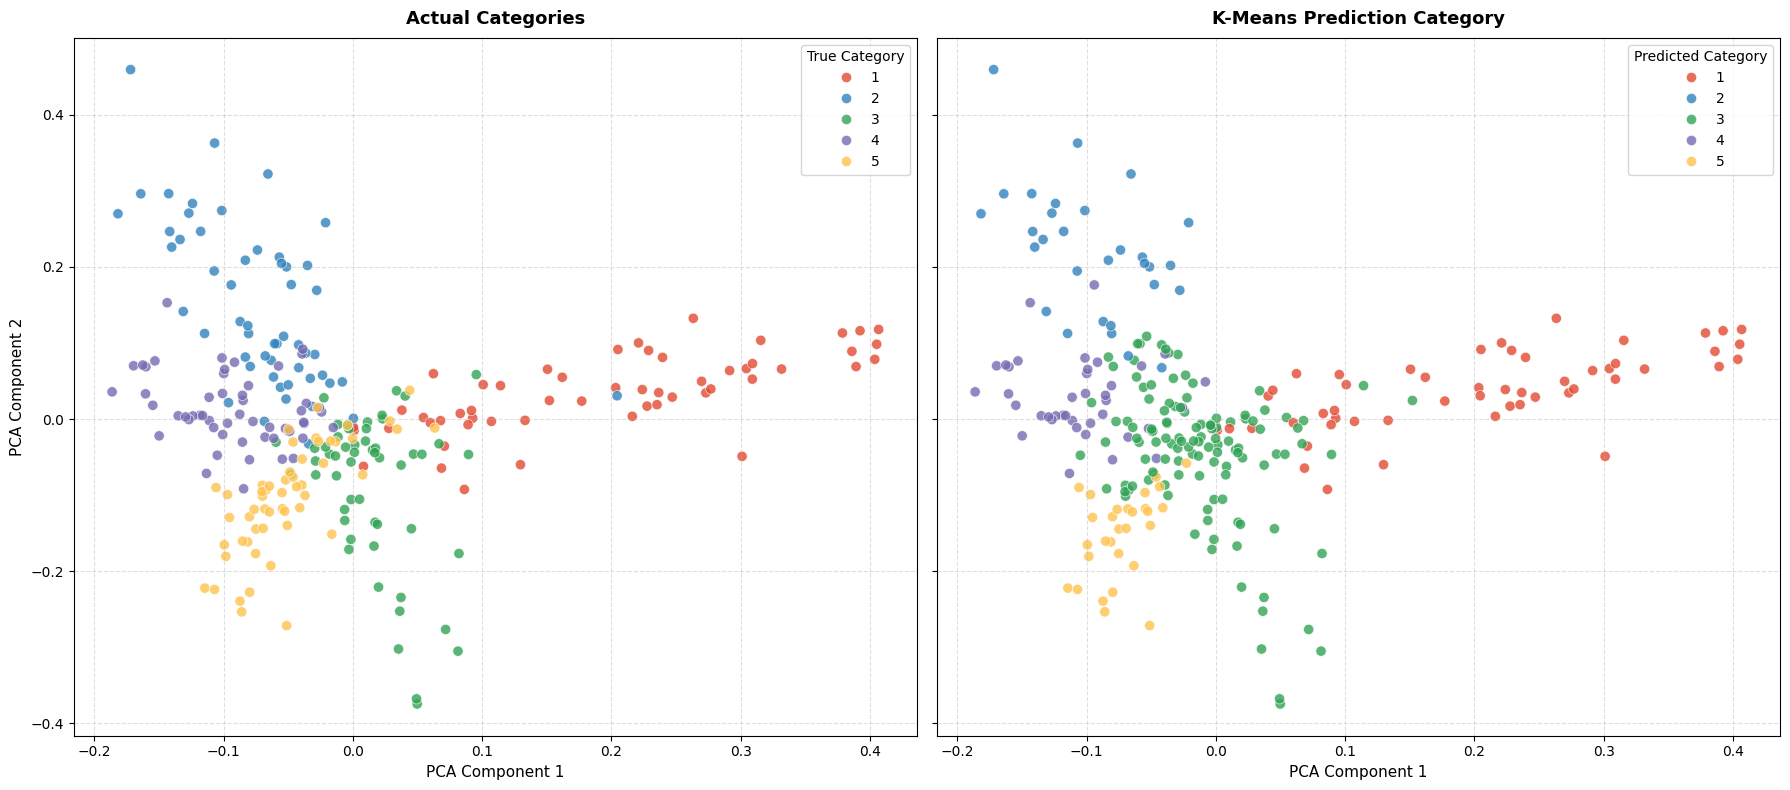

In [323]:
# drop the row with 2 categories
df_mono = df[
    df['category_2'].isna() |
    (df['category_2'].astype(str).str.strip() == 'None') |
    (df['category_2'].astype(str).str.strip() == 'none') |
    (df['category_1'] == df['category_2'])
].copy()
print(df_mono.shape)

# reduce the weight
tfidf_vectorizer = TfidfVectorizer(
    stop_words='english',
    max_df=0.85,
    min_df=2,
    ngram_range=(1, 2)
)

# get the same number of sample in each category.
min_category = df_mono['category_1'].value_counts().min()
print(min_category)

df_bal_cate = df_mono.groupby('category_1').sample(n=min_category ,random_state=RANDOM_STATE).copy()
print(df_bal_cate['category_1'].value_counts())

# K-mean clustering with TF-IDF features on catergory
X_tfidf_cate = tfidf_vectorizer.fit_transform(df_bal_cate['text'])
normalizer = Normalizer(copy=False)
X_tfidf_norm = normalizer.fit_transform(X_tfidf_cate).toarray()

kmeans_category = KMeans(n_clusters=5, init='k-means++', n_init=500,random_state=RANDOM_STATE)
raw_categories = kmeans_category.fit_predict(X_tfidf_norm)
df_bal_cate['cluster_category'] = raw_categories +1
#print(df['cluster_category'].value_counts())

raw_cross_tab_cate = pd.crosstab(df_bal_cate['category_1'], df_bal_cate['cluster_category'])
row_ind, col_ind = linear_sum_assignment(-raw_cross_tab_cate.values)

# Create the decoder map
cluster_to_true_map = {
    raw_cross_tab_cate.columns[col]: raw_cross_tab_cate.index[row]
    for row, col in zip(row_ind, col_ind)
}

# Create new formal columns using the True vs Predicted standard
df_bal_cate['True Category'] = df_bal_cate['category_1']
df_bal_cate['Predicted Category'] = df_bal_cate['cluster_category'].map(cluster_to_true_map)


cross_tab_aligned = pd.crosstab(df_bal_cate['True Category'], df_bal_cate['Predicted Category'])

similarity_matrix = cross_tab_aligned.div(cross_tab_aligned.sum(axis=1), axis=0)

print("\n Similarity Cross table in Percentage")
print((similarity_matrix.round(3) * 100).to_string())


plt.figure(figsize=(9, 7.5))
sns.heatmap(
    similarity_matrix,
    annot=True,
    fmt='.1%',
    cmap='GnBu',
    linewidths=0.5,
    cbar=True,
    annot_kws={"size": 11, "weight": "bold"}
)
plt.title("Purified Semantic Overlap Matrix (Single-Category Docs Only)", fontsize=13, fontweight='bold', pad=15)
plt.xlabel("Predicted Category", fontsize=11)
plt.ylabel("True Category", fontsize=11)
plt.tight_layout()
plt.show()


pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X_tfidf_norm)

df_bal_cate['pca_x'] = X_pca[:, 0]
df_bal_cate['pca_y'] = X_pca[:, 1]

unique_labels = sorted(df_bal_cate['True Category'].unique())
colors_pool = ["#e34a33", "#3182bd", "#31a354", "#756bb1", "#fec44f"]
unified_palette = dict(zip(unique_labels, colors_pool))

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharex=True, sharey=True)

# actual value
sns.scatterplot(
    data=df_bal_cate, x='pca_x', y='pca_y', hue='True Category',
    palette=unified_palette, ax=axes[0], alpha=0.8, s=55, edgecolor='w', linewidth=0.5
)
axes[0].set_title("Actual Categories", fontsize=13, fontweight='bold', pad=10)
axes[0].set_xlabel("PCA Component 1", fontsize=11)
axes[0].set_ylabel("PCA Component 2", fontsize=11)
axes[0].grid(True, linestyle='--', alpha=0.4)

# predicted
sns.scatterplot(
    data=df_bal_cate, x='pca_x', y='pca_y', hue='Predicted Category',
    palette=unified_palette, ax=axes[1], alpha=0.8, s=55, edgecolor='w', linewidth=0.5,
    hue_order=unique_labels
)
axes[1].set_title("K-Means Prediction Category", fontsize=13, fontweight='bold', pad=10)
axes[1].set_xlabel("PCA Component 1", fontsize=11)
axes[1].grid(True, linestyle='--', alpha=0.4)

plt.tight_layout()
plt.show()



**Analyze:** From the Heatmap, there is a diagonal line accross the figure which shows predicted clusters are mirrored to the actual categories. Addtionally, the scatter plots of the Kmean prediction mapped in similar cluster to their actual category. It is noticeable that category 2 has a highest similary to itself with the value of 96.3% while the other catergories are above 60% similar to itself. Therefore, the Kmean model is reliable in predicted the right group.  

From the graph, the category 2 has the highest similar score to the rest of the category compare to the other. It illustrates the similarity score between category 2 and 3 with the value of 46.3%, and following by catergory 4 with the value of 31.4%. From the scatter plot graph, we can see that category 2, 3, and 4 are quite dense to one and the other. However, the scatter plot is condense to 2 dimension, so it is not completely show the whole image, but it can give a rough view that those three catergory are close to each other.


### **Hierachical Clustering**

**Question 2: How do different similarity and linkage methods affect clustering efficiency?**

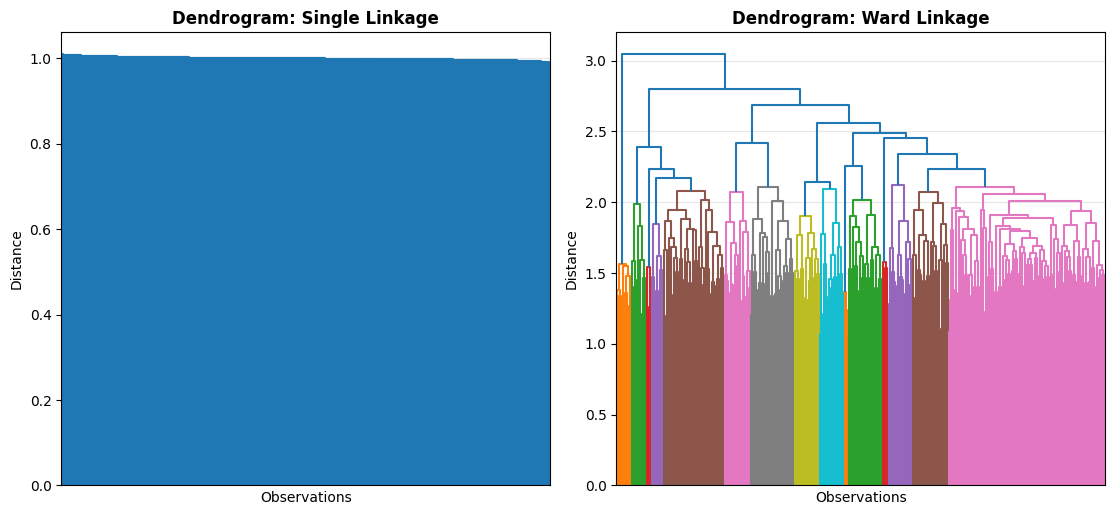

In [324]:
#TFIDF

# Compare different linkage methods
linkage_methods = ['single','ward']
fig, axes = plt.subplots(1, 2, figsize=(11.25, 5.25))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    Z_method = linkage(tfidf_df.dropna(), method=method)
    dendrogram(Z_method, ax=axes[idx], no_labels=True)
    axes[idx].set_title(f'Dendrogram: {method.capitalize()} Linkage', fontweight='bold')
    axes[idx].set_xlabel('Observations')
    axes[idx].set_ylabel('Distance')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analyze**: The first similarity method to test is Term frequency-inverse document frequency (TFIDF). This similarity test combines the term frequency within the document with the inverse frequency of the term within the entire corpus (# of documents in corpus / # of documents containing said term). This measure captures important words within the corpus. When observing the different linkage methods for TFIDF, the only dendrogram that shows any significant clustering is Ward Linkage. This method clusters based off minimizing within-variance between two points. The other three linkage methods do not show any significant clusters for the corpus. This can be due to their different linking methods. Single linkage connects points by their nearest neighbor. This can lead to issues were it becomes a long tail of linkages. If we have any tails within our data, it will naturally form a tail shaped dendrogram. Average and complete linkage follow similar downfalls where the dataset does not form meaningful clusters due to unbalanced distributions.

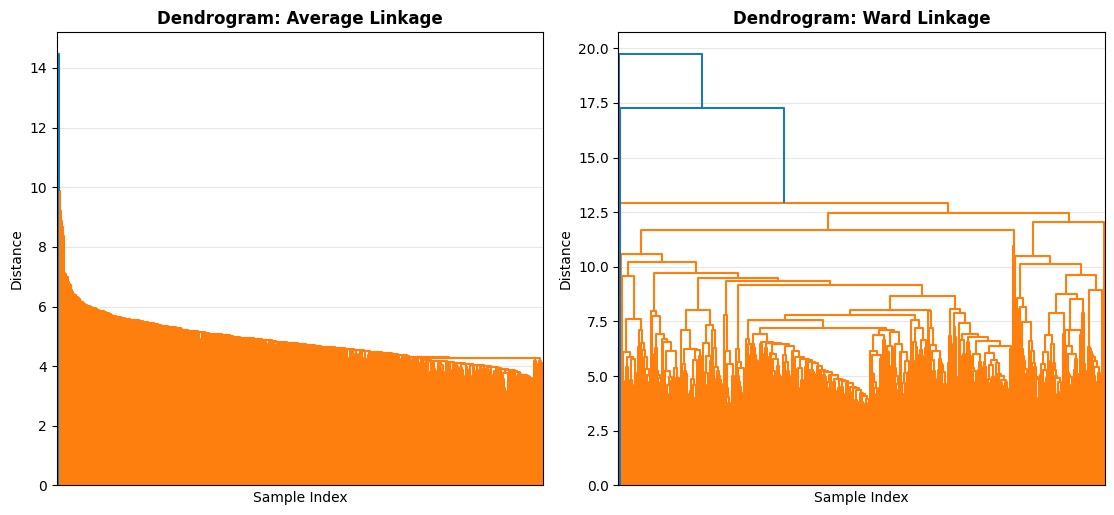

In [325]:
#BOW

# Compare different linkage methods
linkage_methods = ['average', 'ward']
fig, axes = plt.subplots(1, 2, figsize=(11.25, 5.25))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    Z_method = linkage(bow_df.dropna(), method=method)
    dendrogram(Z_method, ax=axes[idx], no_labels=True)
    axes[idx].set_title(f'Dendrogram: {method.capitalize()} Linkage', fontweight='bold')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('Distance')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Anaylze**: The following method used for this comparison is bag of words. Specifically, frequency count for bag of words. This method involves the vectorization of every unique word across the entire corpus. This however brings some imbalanced features, mainly common stop (filler) words into our analysis. Therefore we first vectorize and then promptly filter out the most common filter words. Now we can apply the four different methods of linkage for the dendrogram. Average, complete, and single all fail to create meaningful clusters, while Ward linkage displays the most significant clusters. Overall, the lack of indepth clustering is due to the issues with frequency counts as a measure of similarity because it completely ignores word order. This drastically degrades the clusters meaning because in natural human language we implement sentiment by changing word order. Furthermore, issues arise in this method because of imbalanced word distributions. Words with higher counts would automatically attain higher similarity importance within the clustering process. Overall using word frequency with BoW is not the most optimal for finding meaningful clusters.

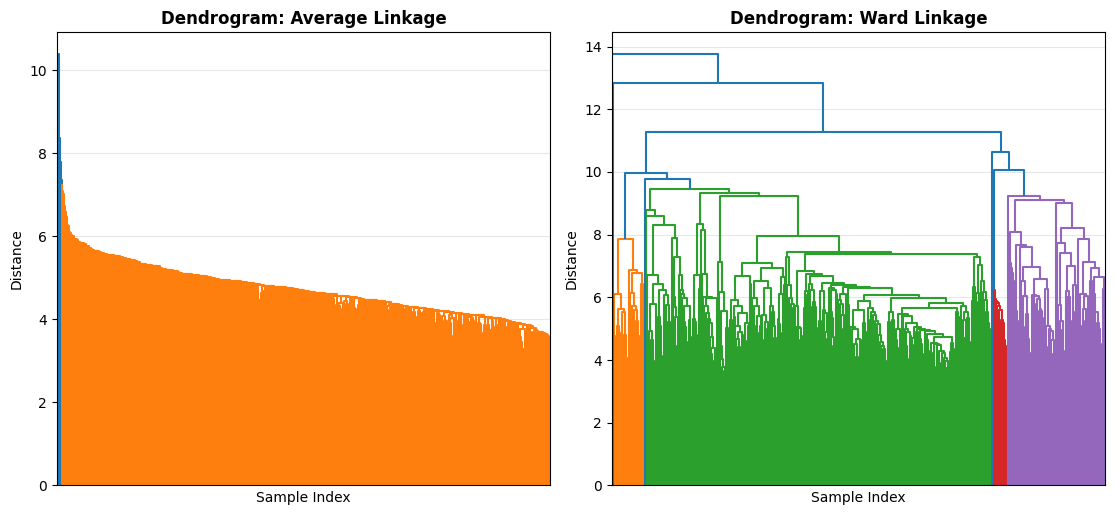

In [326]:
#One-Hot

# Compare different linkage methods
linkage_methods = ['average', 'ward']
fig, axes = plt.subplots(1, 2, figsize=(11.25, 5.25))
axes = axes.ravel()

for idx, method in enumerate(linkage_methods):
    Z_method = linkage(binary_df.dropna(), method=method)
    dendrogram(Z_method, ax=axes[idx], no_labels=True)
    axes[idx].set_title(f'Dendrogram: {method.capitalize()} Linkage', fontweight='bold')
    axes[idx].set_xlabel('Sample Index')
    axes[idx].set_ylabel('Distance')
    axes[idx].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

**Analyze:** The final method of comparing similarity is one-hot encoding. This method involves the vectorization with bag of words, however rather than counting word frequency, it simply stores whether the word exists witin the specificl document. This change in method helps with the distribution issues found in the generic BoW similarity method, however it does not completely get rid of all its issues. Similar to the previous graph, average, single, and complete linkage all suffer from unevenly disributed data. Due to these three linkage methods, they cannot create meaningful clusters. However, ward linkage shows the best over results by clustering the minimum variance between points.

**Overall Summary**: From the various dendrograms created, we can see that overall using TFIDF as a similarity measure works best out of the three used. Furthermore, overall the Ward linkage method for hierarchical clustering proves the best performance compared to the other three methods. Clustering based off the minimum within-variance produces the most meaningful clusters based off the corpus.

### **DBSCAN Clustering**

**Question 3: Do documents naturally cluster by categories?**

For this task, we wanted to see if documents naturally clustered by categories. We used DBScan Clustering on SVD-reduced text that has been vectorized by TF-IDF, and from the clusters, we wanted to see if documents from the same category were put into the same groupings like originally in the corpus.

In [327]:
# reduce dimensionality
svd = TruncatedSVD(n_components = 100, random_state=RANDOM_STATE)
reduced = svd.fit_transform(X_tfidf)

# clustering
db_mod = DBSCAN(eps = 0.6, min_samples = 3)
df['cluster_db'] = db_mod.fit_predict(reduced)

# doc distribution
for cluster_num, group in df.groupby("cluster_db"):
  if cluster_num == -1:
    print(f"Number of Noise/Outliers: {len(group)} docs")
  else:
    print(f"Cluster {cluster_num}: {len(group)} docs")

Number of Noise/Outliers: 250 docs
Cluster 0: 379 docs
Cluster 1: 4 docs
Cluster 2: 4 docs
Cluster 3: 4 docs
Cluster 4: 7 docs
Cluster 5: 3 docs
Cluster 6: 3 docs
Cluster 7: 4 docs
Cluster 8: 5 docs
Cluster 9: 3 docs
Cluster 10: 3 docs
Cluster 11: 3 docs
Cluster 12: 6 docs
Cluster 13: 3 docs
Cluster 14: 3 docs
Cluster 15: 3 docs
Cluster 16: 3 docs
Cluster 17: 3 docs


Original Cross-Tabulation:
cluster_db  -1    0    1    2    3    4    5    6    7    8    9    10   11  \
category_1                                                                    
1            71   93    0    4    0    0    0    0    4    0    0    2    0   
2            58   86    3    0    0    0    1    3    0    0    3    0    0   
3            31   89    0    0    1    2    0    0    0    0    0    1    0   
4            54   72    1    0    3    0    2    0    0    1    0    0    1   
5            36   39    0    0    0    5    0    0    0    4    0    0    2   

cluster_db   12   13   14   15   16   17  
category_1                                
1             0    3    3    1    3    3  
2             2    0    0    0    0    0  
3             4    0    0    2    0    0  
4             0    0    0    0    0    0  
5             0    0    0    0    0    0  


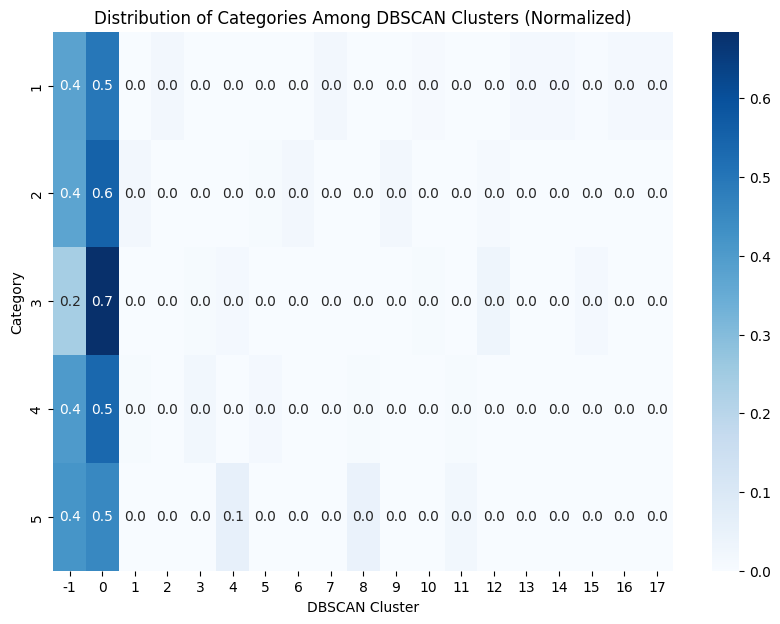

In [328]:
# Distribution of categories across DBSCAN Clusters
cross_tab = pd.crosstab(df["category_1"], df["cluster_db"])
print("Original Cross-Tabulation:")
print(cross_tab)

cross_tab_normalized = cross_tab.div(cross_tab.sum(axis = 1), axis = 0)

plt.figure(figsize=(10, 7))
sns.heatmap(cross_tab_normalized, annot = True, fmt=".1f", cmap ="Blues")
plt.title("Distribution of Categories Among DBSCAN Clusters (Normalized)")
plt.xlabel("DBSCAN Cluster")
plt.ylabel("Category")
plt.show()

**Analyze:** From our results, it seems that the DBScan Clustering identified 17 different clusters and grouped 254 documents as noise and outliers. Notably, we found that more than half of the documents were lumped into one dense cluster, containing a mix of all five categories. The rest of the clusters were relatively small with only 3-6 documents in them, although a few of those clusters generally had documents coming from one category. Overall, it also seems that the documents do not naturally cluster by category given our parameter settings, seeing how multiple categories were sorted into one cluster. A few factors may have contributed to this like categories sharing the same vocabulary words or topics.

## Phase 4: Vader and Sentence-BERT

For Phase 4, we use pretrained NLP models to analyze our corpus. VADER is used to predict sentiment, and Sentence-BERT is used to compare documents by meaning instead of simple word counts. We then compare these results with the methods used in Phases 2 and 3.

### SBERT Emdeddings for Clustering

Checks whether pretrained Sentenced-BERT embeddings create more meaningful document clusters than the TD-IDF vectors used in phase 3.

Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Batches:   0%|          | 0/22 [00:00<?, ?it/s]

SBERT embedding shape:  (693, 384)
Raw SBERT Cluster Cross Table: 
 sbert_cluster   1   2    3   4   5
category_1                        
1               9   5  135  26  12
2              22   4   74  33  23
3              13   9    1  92  15
4              84  30    3   3  14
5               2  39    6   1  38

Aligned SBERT Cluster Cross Table:
Predicted Category    1   2   3   4   5
True Category                          
1                   135  12  26   9   5
2                    74  23  33  22   4
3                     1  15  92  13   9
4                     3  14   3  84  30
5                     6  38   1   2  39

SBERT Adjusted Rand Index: 0.2936


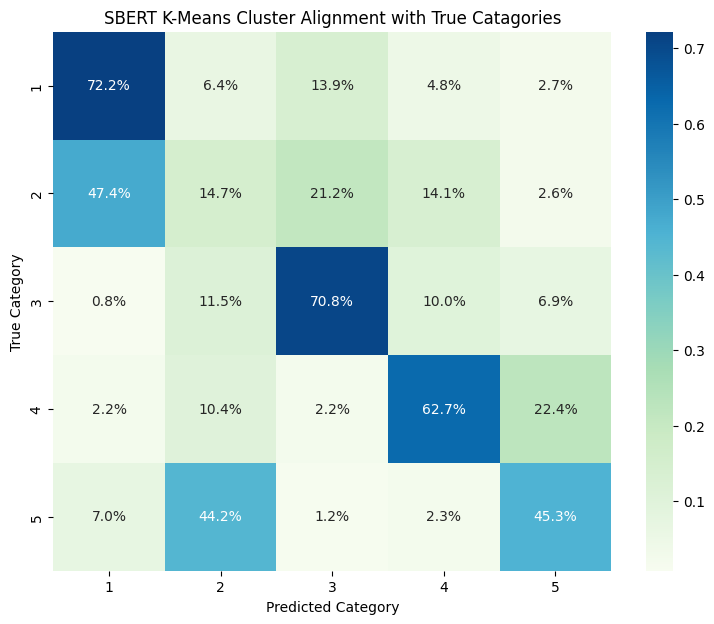

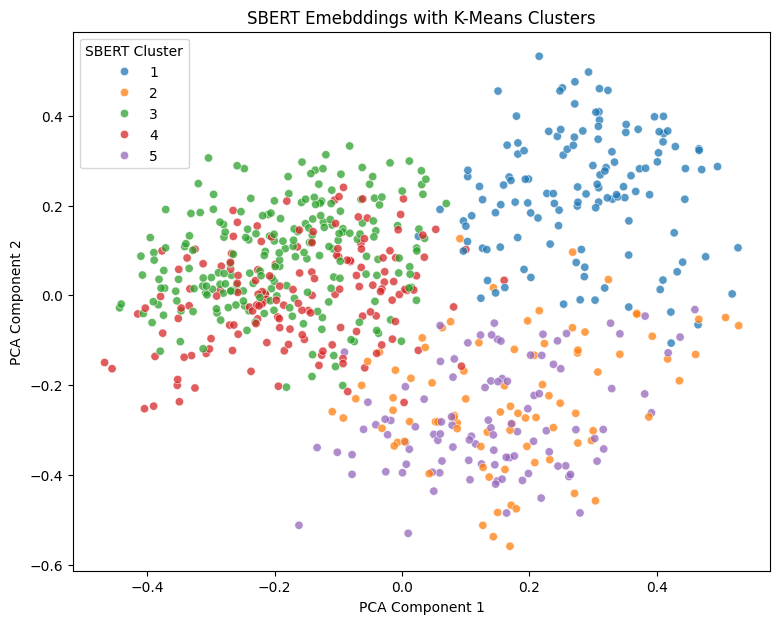

In [329]:
# Convert token-list-looking text back into readable strings
def sbert_clean_text(text):
    text = str(text)
    text = text.replace("[", "").replace("]", "")
    text = text.replace("'", "").replace(",", " ")
    return text

df_sbert = df.copy()
df_sbert["sbert_text"] = df_sbert["text"].apply(sbert_clean_text)

# Load the SBERT model
# If running first time, prepare for loading bars
# Link I used to get a general understanding of all this for python: https://www.sbert.net/docs/package_reference/sentence_transformer/model.html
sbert_model = SentenceTransformer("all-MiniLM-L6-v2")

# Sentence embeddings
sbert_embeddings = sbert_model.encode(
    df_sbert["sbert_text"].tolist(),
    show_progress_bar=True
)

print("SBERT embedding shape: ", sbert_embeddings.shape)

# Use 5 clusters because there are 5 categories
sbert_kmeans = KMeans(
    n_clusters=5,
    random_state=RANDOM_STATE,
    n_init=20
)

df_sbert["sbert_cluster"] = sbert_kmeans.fit_predict(sbert_embeddings) + 1

raw_cross_tab = pd.crosstab(df_sbert["category_1"], df_sbert["sbert_cluster"])
print("Raw SBERT Cluster Cross Table: \n", raw_cross_tab)

# inverse the minimized cost to get the maximized one
row_ind, col_ind = linear_sum_assignment(-raw_cross_tab.values)

cluster_to_true_map = {
    raw_cross_tab.columns[col]: raw_cross_tab.index[row]
    for row, col in zip(row_ind, col_ind)
}

df_sbert["Predicted Category"] = df_sbert["sbert_cluster"].map(cluster_to_true_map)
df_sbert["True Category"] = df_sbert["category_1"]

aligned_cross_tab = pd.crosstab(
    df_sbert["True Category"],
    df_sbert["Predicted Category"]
)

print("\nAligned SBERT Cluster Cross Table:")
print(aligned_cross_tab)

sbert_ari = adjusted_rand_score(
    df_sbert["True Category"],
    df_sbert["sbert_cluster"]
)

print(f"\nSBERT Adjusted Rand Index: {sbert_ari:.4f}")

# Normalize cross table by row
sbert_similarity_matrix = aligned_cross_tab.div(
    aligned_cross_tab.sum(axis="columns"),
    axis="index"
)

plt.figure(figsize=(9, 7))
sns.heatmap(
    sbert_similarity_matrix,
    annot=True,
    fmt="0.1%",
    cmap="GnBu"
)
plt.title("SBERT K-Means Cluster Alignment with True Catagories")
plt.show()

# 2D PCA
pca = PCA(n_components=2, random_state=RANDOM_STATE)
sbert_pca = pca.fit_transform(sbert_embeddings)

df_sbert["pca_x"] = sbert_pca[:, 0]
df_sbert["pca_y"] = sbert_pca[:, 1]

plt.figure(figsize=(9, 7))
sns.scatterplot(
    data=df_sbert,
    x="pca_x",
    y="pca_y",
    hue="sbert_cluster",
    palette="tab10",
    alpha=0.75
)
plt.title("SBERT Emebddings with K-Means Clusters")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend(title="SBERT Cluster")
plt.show()

**Analyze:** SBERT K-Means clustering produced an Adjusted Rand Index of 0.2936 which means the clusters had some relationship with the true catagory labels, but the match was not strong. The clustering performed better than random grouping, but it did not fully recover the original five catagories. 

The heatmap shows that catagories 1, 3, and 4 were the clearest with catagory 1 being mostly correct with 72.2% of those documents falling into that group. Catagory three had 70.8% and catagory 4 had 62.7% fall into their respective predicted catagories. Catagory 2 appears to be confused with catagory 1, with 47.4% of category 2 documents being assigned to the predicted catagory 1. Catagory 5 was also confused with predicted catagory 2 with 44.2% of documents falling into it. Therefore, SBERT most likely has trouble separating certain categories, likely ones that are short and where topics share similar sentence structure or vocabulary.

The PCA scatter plot shows the visible cluster regions. From the scatter plot, we can see there is overlap between clusters 2 and 5 as well as 3 and 4. Thus supporting the ARI score of 0.2936 where there are meaningful groupings, but the clusters are not seperated perfectly into five clean clusters.

Overall, SBERT embeddings helped capture the meaning of the documents better than word-count methods, but the dataset is still difficult to cluster perfectly because many of the documents are short and may combine multiple topics.



## **Group Contribution**


* Andrew Maciborski: Multinominal Naive Bayes, kNN Binary Feature Comparison, Random Forest
* Vincent Chau: Hierarchical Clustering
* Lyda Taing: Tokenization and Vectorization, KNN prediction sentiment, Kmean Q1
* Christie Wong: Logistic Regression, DBSCAN Clustering
* Daniel Remedios: KNN, SVM, SBERT Embeddings for Clustering

In [330]:
#submisson
# !sudo apt-get update
# !sudo apt-get install texlive-xetex texlive-fonts-recommended texlive-plain-generic pandoc
# !pip install pypandoc
# !jupyter nbconvert --log-level DEBUG --to pdf "Team_5_Phase_2_3.ipynb"